In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set fontsize in matplotlib to 18
plt.rcParams.update({'font.size': 14})

**Worked example of discretized Rayleigh fractionation**

Here the effect of temperature step size on the depletion of trace elements is demonstrated by considering a simple example. A arbitrary temperature interval mapped onto [0,1] is considered. Melt fraction is held constant at 0.8, as is often observed in fractional crystallization runs. Mineral-melt partition coefficient D is assumed to continuously increase from 1 to 10 in this temperature interval.





In [ ]:
# Defininng the temperature range, melt fraction and partition coefficients
Ts = np.linspace(0,1,10)
F = np.ones_like(Ts)*0.8
D  = lambda t: 1 + 9*t

In [ ]:
# Plot of F and D, using the left y-axis for F and the right y-axis for D
def plot_F_D(Ts, F, D):
    fig, ax1 = plt.subplots()
    ax1.plot(Ts, F, 'b-', label='F')
    ax1.set_xlabel('Ts')
    ax1.set_ylabel('F', color='b') 
    # Set y-ticks to blue color
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(Ts, D(Ts), color='orange', linestyle='-', label='D')
    ax2.set_ylabel('D', color='orange')
    # Set y-ticks to red color
    ax2.tick_params(axis='y', labelcolor='orange')

    return fig, ax1, ax2

**Case 1: Step size = 0.5, equal to two steps**

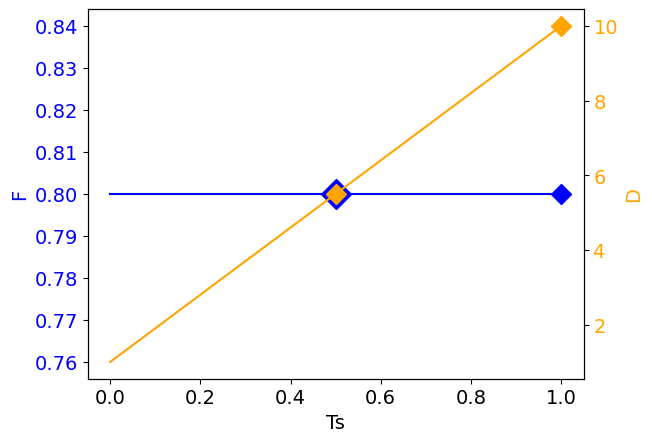

In [20]:
fig, ax1, ax2 = plot_F_D(Ts, F, D)

ax1.plot(0.5, F[np.argmin(np.abs(Ts-0.5))], 'bD', markersize=15, zorder=5)
ax1.plot(1, F[np.argmin(np.abs(Ts-1))], 'bD', markersize=10, zorder=0)
ax2.plot(0.5, D(0.5), color='orange', marker='D', markersize=10)
ax2.plot(1, D(1), color='orange', marker='D', markersize=10)


In [ ]:
Fs = np.array([F[np.argmin(np.abs(Ts-0.5))], F[np.argmin(np.abs(Ts-1))]])
Ds = np.array([D(0.5), D(1)])

# Compute depletion factors 1/[D+F(1-D)] across all steps

depletion_factors = 1 / (Ds + Fs * (1 - Ds))

Depletion factors are defined as

$$\frac{C_L}{C_0} = \frac{1}{D+F(1-D)}$$

Step 1: $\frac{C_L}{C_0}$ = 0.526

Step 2: $\frac{C_L}{C_0}$ = 0.357

**Cumulative: 0.526 $\times$ 0.357 = 0.188**

**Case 2: Step size = 0.25, equal to four steps**

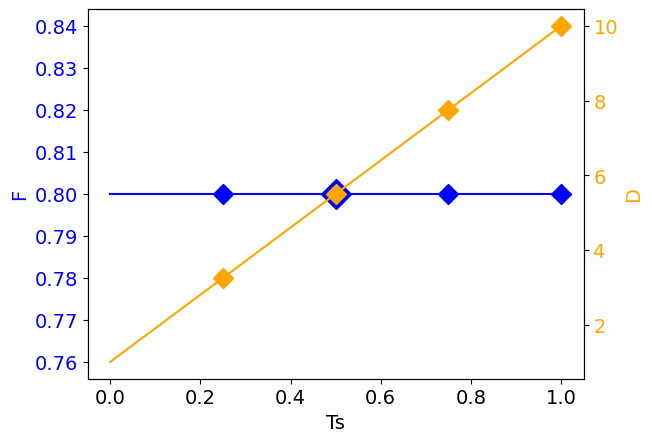

In [21]:
fig, ax1, ax2 = plot_F_D(Ts, F, D)

ax1.plot(0.25, F[np.argmin(np.abs(Ts-0.25))], 'bD', markersize=10, zorder=0)
ax1.plot(0.5, F[np.argmin(np.abs(Ts-0.5))], 'bD', markersize=15, zorder=5)
ax1.plot(0.75, F[np.argmin(np.abs(Ts-0.75))], 'bD', markersize=10, zorder=0)
ax1.plot(1, F[np.argmin(np.abs(Ts-1))], 'bD', markersize=10, zorder=0)
ax2.plot(0.25, D(0.25), color='orange', marker='D', markersize=10)
ax2.plot(0.5, D(0.5), color='orange', marker='D', markersize=10)
ax2.plot(0.75, D(0.75), color='orange', marker='D', markersize=10)
ax2.plot(1, D(1), color='orange', marker='D', markersize=10)

In [ ]:
Fs = np.array([F[np.argmin(np.abs(Ts-0.25))], F[np.argmin(np.abs(Ts-0.5))], F[np.argmin(np.abs(Ts-0.75))], F[np.argmin(np.abs(Ts-1))]])
Ds = np.array([D(0.25), D(0.5), D(0.75), D(1)])

# Compute depletion factors 1/[D+F(1-D)] across all steps

depletion_factors = 1 / (Ds + Fs * (1 - Ds))

Step 1: $\frac{C_L}{C_0}$ = 0.690

Step 2: $\frac{C_L}{C_0}$ = 0.526

Step 3: $\frac{C_L}{C_0}$ = 0.426

Step 4: $\frac{C_L}{C_0}$ = 0.357


**Cumulative: 0.690 $\times$ 0.526 $\times$ 0.426 $\times$ 0.357 = 0.055**

**Comparing the results**

Step size = 0.5, two steps: $\frac{C_L}{C_0}$ = 0.188

Step size = 0.25, four steps: $\frac{C_L}{C_0}$ = 0.055

Halfing the step size has led to more than 3 times more depletion.